In [1]:
import sys
import os
working_path = './proj2_data/'
sys.path.append(working_path )
os.chdir(working_path )

In [2]:
DATA_NAME_PATH = 'apparel/'
DATASET_PATH = DATA_NAME_PATH + 'dataset/'

class_list = ['dress', 'pants', 'shirt', 'shoes']
print(class_list)
class_len = len(class_list)
print(class_len)

IMG_SIZE = 224
BATCH_SIZE = 8

['dress', 'pants', 'shirt', 'shoes']
4


### Load Dataset (or Equivalent)

In [3]:
# Images saved in folders with the following patterns
# Images finally saved in folders with the following patterns
# data_path/
#     train/
#        class0/
#           classs0_0.jpg
#           ...
#           classs0_k.jpg
#       class1/
#         classs1_0.jpg
#         ...
#         classs1_k.jpg
#       ...
#       classN/
#         classsN_0.jpg
#         ...
#         classsN_k.jpg
#     validation/
#        class0/
#        ...
#        classN/
#     test/
#        class0/
#        ...
#        classN
# npy/
#     X_train.npy
#     y_train.npy
#     X_test.npy
#     y_test.npy

In [4]:
# Load numpy_files
import numpy as np

NUMPY_PATH = DATA_NAME_PATH + 'npy/'
print(NUMPY_PATH)

# Comment out the loading part for now, as we need to regenerate the files first.
X_train = np.load(NUMPY_PATH + 'X_train.npy')
y_train = np.load(NUMPY_PATH + 'y_train.npy')

X_val = np.load(NUMPY_PATH + 'X_val.npy')
y_val = np.load(NUMPY_PATH + 'y_val.npy')

X_test = np.load(NUMPY_PATH + 'X_test.npy')
y_test = np.load(NUMPY_PATH + 'y_test.npy')

apparel/npy/


In [5]:
X_train.shape

(640, 224, 224, 3)

In [6]:
IMG_SIZE = X_train.shape[1]
print(IMG_SIZE)

224


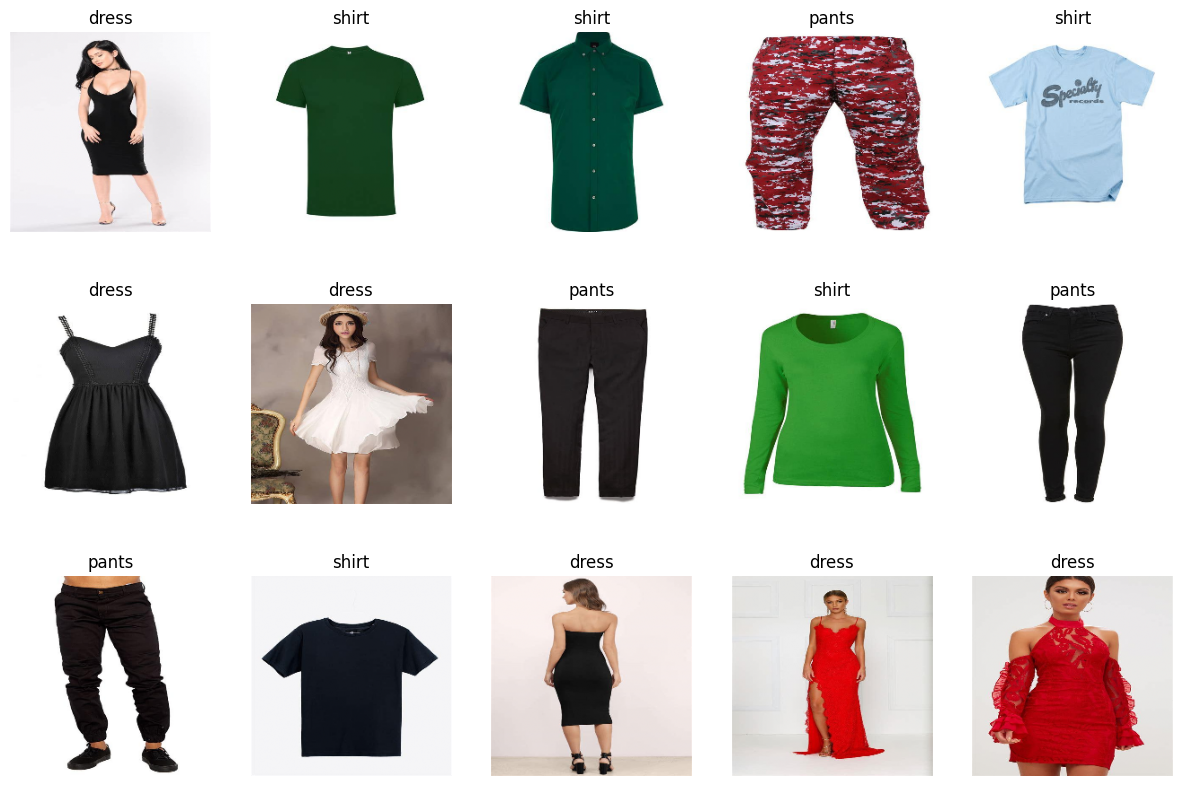

In [7]:
# Display a few images and labels
import matplotlib.pyplot as plt
%matplotlib inline

class_names = np.array(class_list)

plt.figure(figsize=(15,10))
inx = np.random.choice(X_train.shape[0], 15, replace=False)
for n, i in enumerate(inx):
    ax = plt.subplot(3,5,n+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')

### Load Existing Deep Learning Model

In [8]:
import tensorflow as tf

In [9]:
# [UPDATED]
# Uncommment pre-trained model of your choice

'''
base_model = tf.keras.applications.MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                                                include_top=False,
                                                weights="imagenet"
                                                )
'''

'''
base_model = tf.keras.applications.VGG16(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                                         include_top=False,
                                         weights="imagenet"
                                        )
'''

base_model = tf.keras.applications.ResNet50(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                                            include_top=False,
                                            weights="imagenet"
                                          )

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
for layer in base_model.layers:
    print(layer.name, layer.output.shape)

input_layer (None, 224, 224, 3)
conv1_pad (None, 230, 230, 3)
conv1_conv (None, 112, 112, 64)
conv1_bn (None, 112, 112, 64)
conv1_relu (None, 112, 112, 64)
pool1_pad (None, 114, 114, 64)
pool1_pool (None, 56, 56, 64)
conv2_block1_1_conv (None, 56, 56, 64)
conv2_block1_1_bn (None, 56, 56, 64)
conv2_block1_1_relu (None, 56, 56, 64)
conv2_block1_2_conv (None, 56, 56, 64)
conv2_block1_2_bn (None, 56, 56, 64)
conv2_block1_2_relu (None, 56, 56, 64)
conv2_block1_0_conv (None, 56, 56, 256)
conv2_block1_3_conv (None, 56, 56, 256)
conv2_block1_0_bn (None, 56, 56, 256)
conv2_block1_3_bn (None, 56, 56, 256)
conv2_block1_add (None, 56, 56, 256)
conv2_block1_out (None, 56, 56, 256)
conv2_block2_1_conv (None, 56, 56, 64)
conv2_block2_1_bn (None, 56, 56, 64)
conv2_block2_1_relu (None, 56, 56, 64)
conv2_block2_2_conv (None, 56, 56, 64)
conv2_block2_2_bn (None, 56, 56, 64)
conv2_block2_2_relu (None, 56, 56, 64)
conv2_block2_3_conv (None, 56, 56, 256)
conv2_block2_3_bn (None, 56, 56, 256)
conv2_block2_ad

In [11]:
base_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

### Feature Extraction: Construct Your Model

In [12]:
from tensorflow.keras.models import  Sequential, Model, load_model

final_model = tf.keras.Sequential([base_model,
                                  tf.keras.layers.GlobalAveragePooling2D(),
                                  tf.keras.layers.BatchNormalization(),
                                  tf.keras.layers.Dense(128, activation='relu'),
                                  tf.keras.layers.Dropout(0.5),
                                  tf.keras.layers.Dense(class_len, activation='softmax')  # For multi-class
                            ])
# Notice that the last layer, the output size is equal to number of classes

In [13]:
y_train

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [14]:
# Compile Model

final_model.layers[0].trainable = False
final_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                    loss='sparse_categorical_crossentropy',  # classes = 0,1,2,3..'
                    #loss='categorical_crossentropy',        # classes = one hot
                    metrics = ["accuracy"]
)

In [15]:
for layer in final_model.layers:
    print(layer.name, layer.output.shape)

resnet50 (None, 7, 7, 2048)
global_average_pooling2d (None, 2048)
batch_normalization (None, 2048)
dense (None, 128)
dropout (None, 128)
dense_1 (None, 4)


In [16]:
final_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,858,692 (91.01 MB)

 Trainable params: 266,884 (1.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [17]:
# For resizing images that are not 224 x 224
#X_train_resized = tf.image.resize(X_train, IMG_SIZE)
#X_val_resized = tf.image.resize(X_val, IMG_SIZE)
#X_test_resized = tf.image.resize(X_test, IMG_SIZE)

#print(f"Resized training images shape: {X_train_resized.shape}")
#print(f"Resized training images shape: {X_val_resized.shape}")
#print(f"Resized validation images shape: {X_test_resized.shape}")

In [18]:
# [UPDATED]

# Uncomment below Data Augmentation
# To apply augmentation, (X_train, y_train) are combined to a dataset ds for tensor flow augmentation functions
'''
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),  # flip horizontally
    tf.keras.layers.RandomRotation(0.2),       # 0.2 = rotate +/- 20% of 360 degress = +/- 72
    tf.keras.layers.RandomZoom(0.2)            # 0.2 = 80%-120% of original size
])

train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))
test_ds = test_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

# If using this, make sure the following code uses tensorflow dataset
'''

'\ntrain_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))\n\ndata_augmentation = tf.keras.Sequential([\n    tf.keras.layers.RandomFlip("horizontal"),  # flip horizontally\n    tf.keras.layers.RandomRotation(0.2),       # 0.2 = rotate +/- 20% of 360 degress = +/- 72\n    tf.keras.layers.RandomZoom(0.2)            # 0.2 = 80%-120% of original size\n])\n\ntrain_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))\ntest_ds = test_ds.map(lambda x, y: (data_augmentation(x, training=True), y))\n\n# If using this, make sure the following code uses tensorflow dataset\n'

In [19]:
# [UPDATED]
# Uncommment proprocess according to your pre-trained model

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
# X_train_processed = tf.keras.applications.mobilenet_v2.preprocess_input(X_train)
# X_val_processed = tf.keras.applications.mobilenet_v2.preprocess_input(X_val)
# X_test_processed = tf.keras.applications.mobilenet_v2.preprocess_input(X_test)

# from tensorflow.keras.applications.vgg16 import preprocess_input
# X_train_processed = tf.keras.applications.vgg16.preprocess_input(X_train)
# X_val_processed = tf.keras.applications.vgg16.preprocess_input(X_val)
# X_test_processed = tf.keras.applications.vgg16.preprocess_input(X_test)

# from tensorflow.keras.applications.resnet50 import preprocess_input
X_train_processed = tf.keras.applications.resnet50.preprocess_input(X_train)
X_val_processed = tf.keras.applications.resnet50.preprocess_input(X_val)
X_test_processed = tf.keras.applications.resnet50.preprocess_input(X_test)


In [20]:
# stops model training when the validation performance stops improving.
earlystopping = tf.keras.callbacks.EarlyStopping(patience=2,          # how many epochs the model waits before stopping.
                                                 monitor="val_loss",  # After every epoch, the model checks validation loss
                                                 restore_best_weights=True  # the model restores the weights from the best epoch.
                                                 )


history_model = final_model.fit(X_train_processed, y_train,
                                epochs=20,                # Maximum number of training cycles.
                                batch_size=BATCH_SIZE,    # #training images that the model processes before updating its weights once.
                                validation_data=(X_val_processed, y_val),   # Use this dataset to compute validation loss
                                callbacks=[earlystopping]
                                )


Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 20s 86ms/step - accuracy: 0.6297 - loss: 0.9236 - val_accuracy: 0.4000 - val_loss: 1.3830
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.7422 - loss: 0.6603 - val_accuracy: 0.4875 - val_loss: 1.0519
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.8031 - loss: 0.5195 - val_accuracy: 0.7875 - val_loss: 0.8046
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.7953 - loss: 0.5526 - val_accuracy: 0.7875 - val_loss: 0.7269
Epoch 5/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.8281 - loss: 0.4658 - val_accuracy: 0.7875 - val_loss: 0.5997
Epoch 6/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.8484 - loss: 0.3859 - val_accuracy: 0.8000 - val_loss: 0.4993
Epoch 7/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.8594 - loss: 0.4040 - val_accuracy: 0.7750 - val_loss: 0.4539
Epoch 8/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.8703 - loss: 0.3498 - val_accuracy: 0.7625 - 

In [21]:
final_model.save('resnet50_transfer.keras')

In [22]:
# [UPDATED]
# To load model
# model = tf.keras.models.load_model(DATA_NAME_PATH + 'transfer_learning_model.keras')

### Performance Evaluation

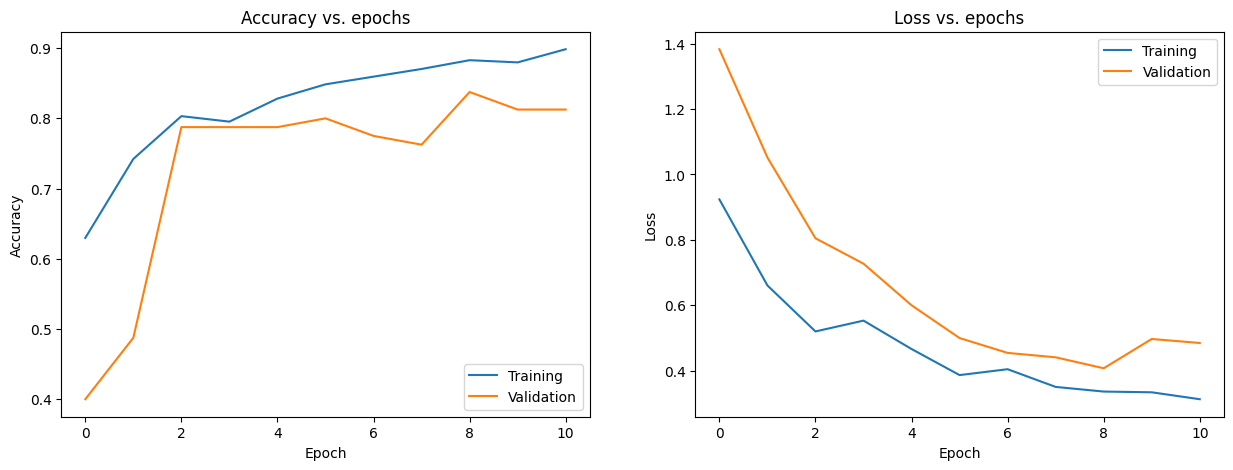

In [23]:
# Plot the learning curves
import matplotlib.pyplot as plt
plt.figure(figsize=(15,5))
plt.subplot(121)
plt.subplot(121)
try:
    plt.plot(history_model.history['accuracy'])
    plt.plot(history_model.history['val_accuracy'])
except KeyError:
    plt.plot(history_model.history['acc'])
    plt.plot(history_model.history['val_acc'])
plt.title('Accuracy vs. epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.subplot(122)
plt.plot(history_model.history['loss'])
plt.plot(history_model.history['val_loss'])
plt.title('Loss vs. epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.show()

In [24]:
new_model_test_loss, new_model_test_acc = final_model.evaluate(X_test_processed, y_test, verbose=0)
print("Test loss: {}".format(new_model_test_loss))
print("Test accuracy: {}".format(new_model_test_acc))

Test loss: 0.38703808188438416
Test accuracy: 0.862500011920929


In [25]:
predictions = final_model.predict(X_test_processed)
predictions

3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step


array([[9.07746792e-01, 2.79122777e-02, 5.49983084e-02, 9.34252609e-03],
       [9.36499894e-01, 6.10258570e-03, 5.61547950e-02, 1.24274776e-03],
       [6.36005938e-01, 1.27140120e-01, 1.36253983e-01, 1.00599959e-01],
       [6.09922707e-01, 1.12641696e-02, 3.58789116e-01, 2.00239532e-02],
       [8.22458565e-01, 6.91456906e-03, 1.42553985e-01, 2.80728359e-02],
       [2.37027451e-01, 3.29303473e-01, 9.84049663e-02, 3.35264057e-01],
       [7.74431348e-01, 3.14875878e-02, 7.56051838e-02, 1.18475839e-01],
       [9.46249187e-01, 5.62304165e-03, 4.78455648e-02, 2.82291498e-04],
       [9.87466276e-01, 9.88532789e-04, 1.12715624e-02, 2.73651589e-04],
       [9.40901995e-01, 9.86287650e-03, 3.40832546e-02, 1.51518704e-02],
       [1.33039072e-01, 2.44394824e-01, 1.27781302e-01, 4.94784802e-01],
       [8.92804205e-01, 3.49230096e-02, 6.56645894e-02, 6.60817837e-03],
       [1.90134302e-01, 1.71586514e-01, 9.73702148e-02, 5.40908992e-01],
       [8.30839694e-01, 5.90548329e-02, 9.30384472e

In [26]:
y_predicted = np.argmax(predictions, axis=1)
y_predicted

array([0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 3, 0, 3, 0, 0, 2, 1, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2,
       2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 1, 3, 3, 3, 3,
       0, 3, 3, 3, 3, 3, 0, 3, 3, 1, 3, 3, 3, 3])

In [27]:
# import numpy as np

# predicted_classes = [class_names[x] for x in y_predicted]

# y_test = []
# for images, labels in test_ds_processed:
#    y_test.extend(labels.numpy())

# y_test = np.array(y_test)
# true_classes = [class_names[x] for x in y_test]

predicted_classes = [class_names[x] for x in y_predicted]
true_classes = [class_names[x] for x in y_test]

In [28]:
len(y_predicted)
len(y_test)

80

In [29]:
import pandas as pd

results_df = pd.DataFrame({
    "Actual": true_classes,
    "Predicted": predicted_classes,
})
results_df.head()

,Actual,Predicted
0,dress,dress
1,dress,dress
2,dress,dress
3,dress,dress
4,dress,dress


In [30]:
results_df["Correct"] = results_df["Actual"] == results_df["Predicted"]
num_correct = results_df["Correct"].sum()
print("Total Predictons: ", len(results_df), ", Correct predictions:", num_correct, ' Correct Percent: ', num_correct/len(results_df))

Total Predictons:  80 , Correct predictions: 69  Correct Percent:  0.8625


In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_classes, predicted_classes)
print(cm)

[[15  1  1  3]
 [ 0 20  0  0]
 [ 1  1 18  0]
 [ 2  2  0 16]]


In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_predicted, target_names=class_names))

              precision    recall  f1-score   support

       dress       0.83      0.75      0.79        20
       pants       0.83      1.00      0.91        20
       shirt       0.95      0.90      0.92        20
       shoes       0.84      0.80      0.82        20

    accuracy                           0.86        80
   macro avg       0.86      0.86      0.86        80
weighted avg       0.86      0.86      0.86        80



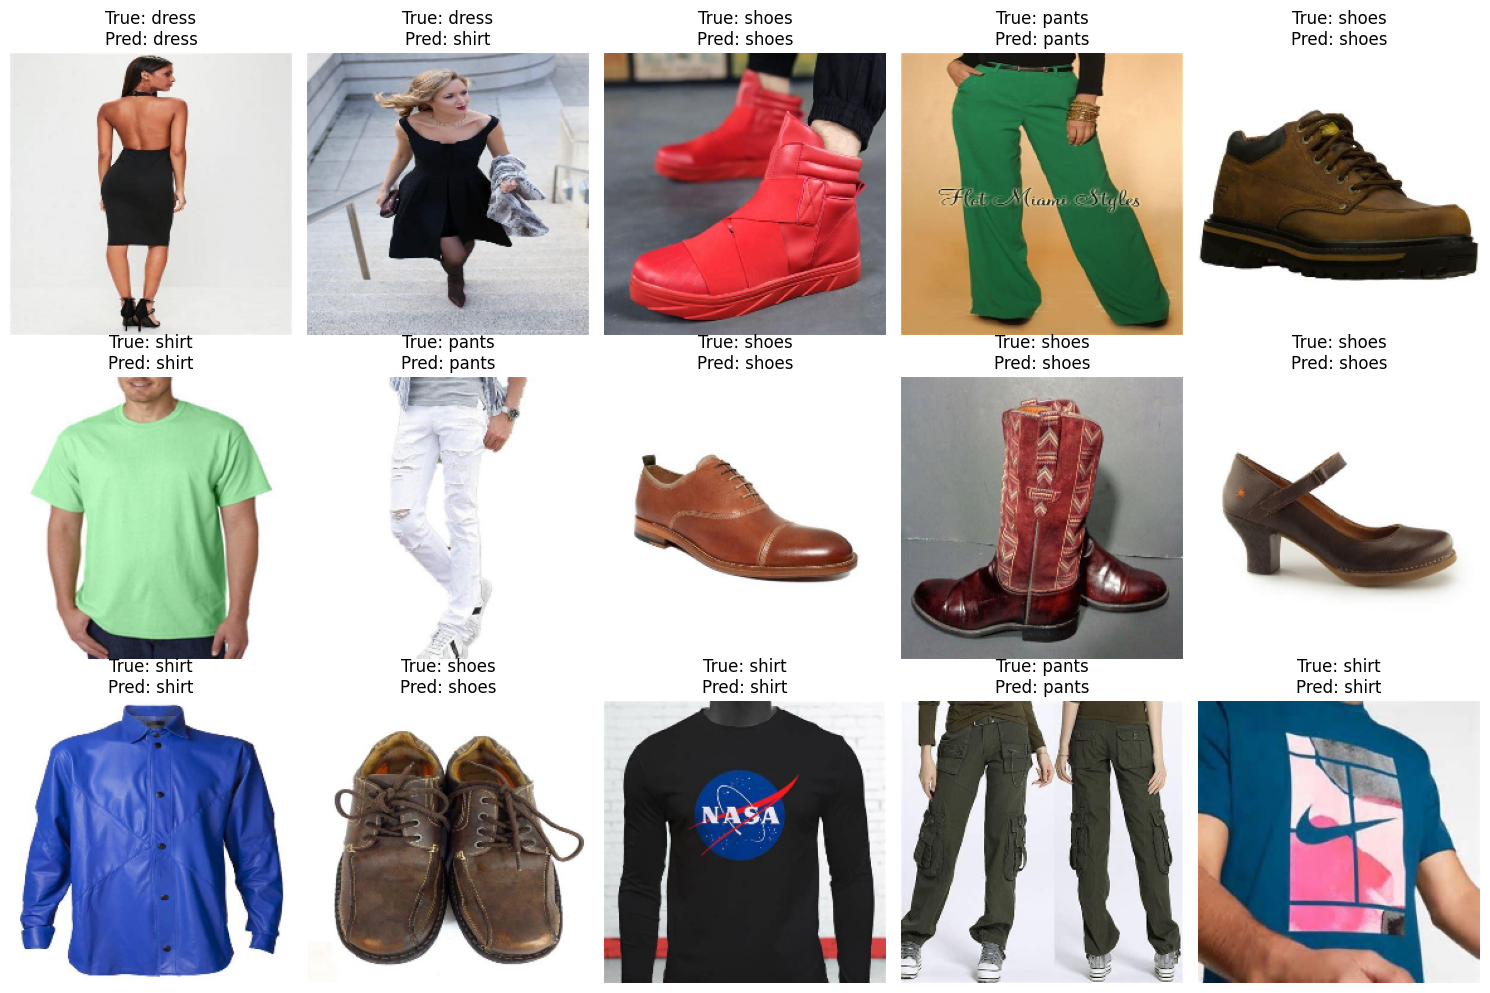

In [33]:
clean_X_test = np.load(NUMPY_PATH + 'X_test.npy')

plt.figure(figsize=(15,10))

# Random sample of test images
inx = np.random.choice(clean_X_test.shape[0], 15, replace=False)

for n, i in enumerate(inx):
    ax = plt.subplot(3,5,n+1)
    # img = (X_test[i] + 1) / 2
    # plt.imshow(img*255)
    plt.imshow(clean_X_test[i])
    # plt.imshow(X_test[i] * 255)

    true_label = true_classes[i]
    pred_label = predicted_classes[i]

    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()